In [1]:
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import models, layers, callbacks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matp1tlib.pyplot as viz_format
from datetime import datetime, timedelta
from warnings import filterwarnings
plt.style.use('fivethirtyeight')
filterwarnings('ignore')
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


Available Companies:
1: CIB
2: Talaat Moustafa Group
3: Fawry
4: El Sewedy Electric
5: Ibnsina Pharma
6: Telecom Egypt
7: Egypt Aluminum 

Choose a company number (1-7): 3

Analyzing: Fawry (FWRY.CA)...
Data Loaded Successfully!
Last Price: 16.17 EGP


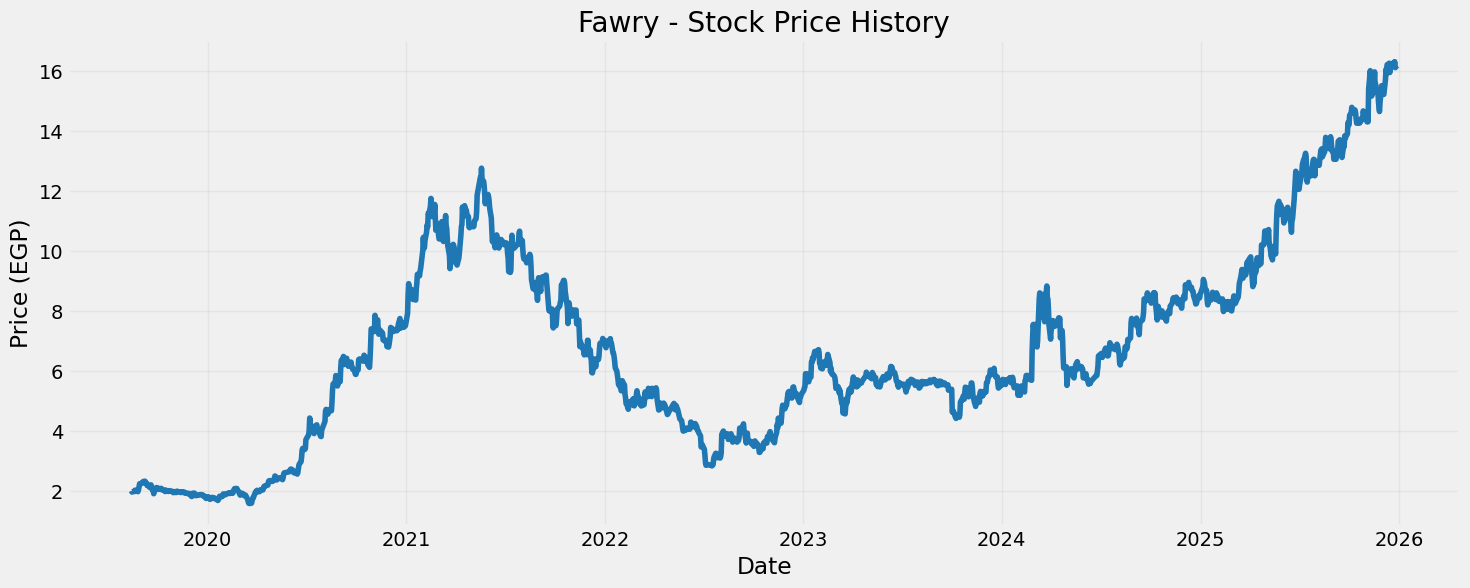

In [2]:
stocks = {
    "1": ("CIB", "COMI.CA"),
    "2": ("Talaat Moustafa Group", "TMGH.CA"),
    "3": ("Fawry", "FWRY.CA"),
    "4": ("El Sewedy Electric", "SWDY.CA"),
    "5": ("Ibnsina Pharma", "ISPH.CA") ,
    "6": ("Telecom Egypt", "ETEL.CA"),
    "7": ("Egypt Aluminum ", "EGAL.CA"),
}

print("Available Companies:")
for key, (name, _) in stocks.items():
    print(f"{key}: {name}")

choice = input("\nChoose a company number (1-7): ")
ticker_name, ticker = stocks.get(choice, stocks["1"])

print(f"\nAnalyzing: {ticker_name} ({ticker})...")
print("==========================================")

try:
    data = yf.download(ticker, start='2015-01-01', progress=False)
except Exception as e:
    print(f"Error downloading data: {e}")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.reset_index(inplace=True)

if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.set_index('Date')
elif 'Datetime' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Datetime'])
    data = data.set_index('Datetime')

if 'Close' in data.columns:
    data.rename(columns={'Close': 'Price'}, inplace=True)
elif 'Adj Close' in data.columns:
    data.rename(columns={'Adj Close': 'Price'}, inplace=True)
else:
    raise ValueError("Could not find 'Close' column!")

data.dropna(subset=['Price'], inplace=True)

print(f"Data Loaded Successfully!")
print(f"Last Price: {data['Price'].iloc[-1]:.2f} EGP")
plt.figure(figsize=(16,6))
plt.plot(data['Price'], color='#1f77b4')
plt.title(f'{ticker_name} - Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price (EGP)')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
features = data['Price'].values.reshape(-1,1)

train_size = int(len(features) * 0.8)
test_size = len(features) - train_size

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(features)

training = scaled_data[:train_size]
time_steps = 60
x_train, y_train = [], []

for i in range(time_steps, len(training)):
    x_train.append(training[i-time_steps:i, 0])
    y_train.append(training[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

test_features = scaled_data[train_size - time_steps:]
x_test, y_test = [], []

for i in range(time_steps, len(test_features)):
    x_test.append(test_features[i-time_steps:i, 0])
    y_test.append(test_features[i, 0])

x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
y_test = np.array(y_test)

print(f'Train Shape: {x_train.shape}, Test Shape: {x_test.shape}')

Train Shape: (1180, 60, 1), Test Shape: (310, 60, 1)


In [4]:
model = models.Sequential([
    layers.LSTM(50, return_sequences=True, input_shape=(x_train.shape[1],1)),
    layers.Dropout(0.2),

    layers.LSTM(50, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(50, return_sequences=False),
    layers.Dropout(0.2),

    layers.Dense(25, activation='relu'),
    layers.Dense(1, activation='linear')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='mse', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0414 - mean_absolute_error: 0.1497
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0043 - mean_absolute_error: 0.0471
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0030 - mean_absolute_error: 0.0408
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0031 - mean_absolute_error: 0.0404
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0024 - mean_absolute_error: 0.0358
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 178ms/step - loss: 0.0020 - mean_absolute_error: 0.0337
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - loss: 0.0022 - mean_absolute_error: 0.0344
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0021 - mean_absolute_error: 0.0334
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 0.0018 - mean_absolute_error: 0.0308
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0020 - mean_absolute_error: 0.0329
Epoch 11/100
37/37 ━━━━━

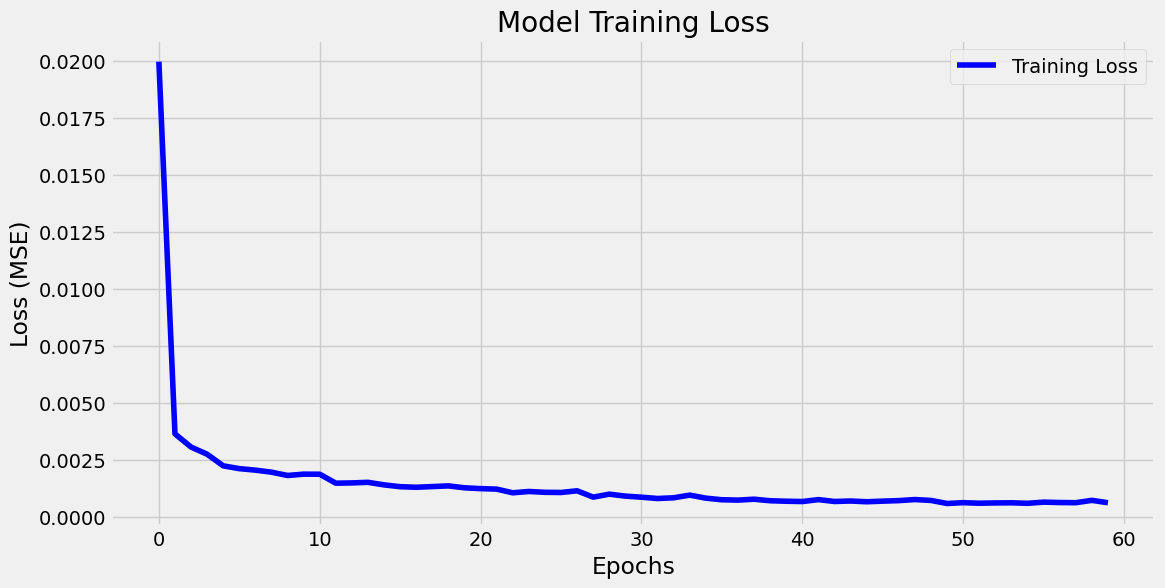

In [5]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
)

plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title("Model Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

In [6]:
predictions = model.predict(x_test)

predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


rmse = np.sqrt(np.mean((y_test_real - predictions_real)**2))

mape = np.mean(np.abs((y_test_real - predictions_real) / y_test_real)) * 100

accuracy = 100 - mape

print("\n---------------- Model Performance ----------------")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} EGP")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy (Approx): {accuracy:.2f}%")
print("---------------------------------------------------")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step

---------------- Model Performance ----------------
Root Mean Squared Error (RMSE): 0.65 EGP
Mean Absolute Percentage Error (MAPE): 4.08%
Model Accuracy (Approx): 95.92%
---------------------------------------------------


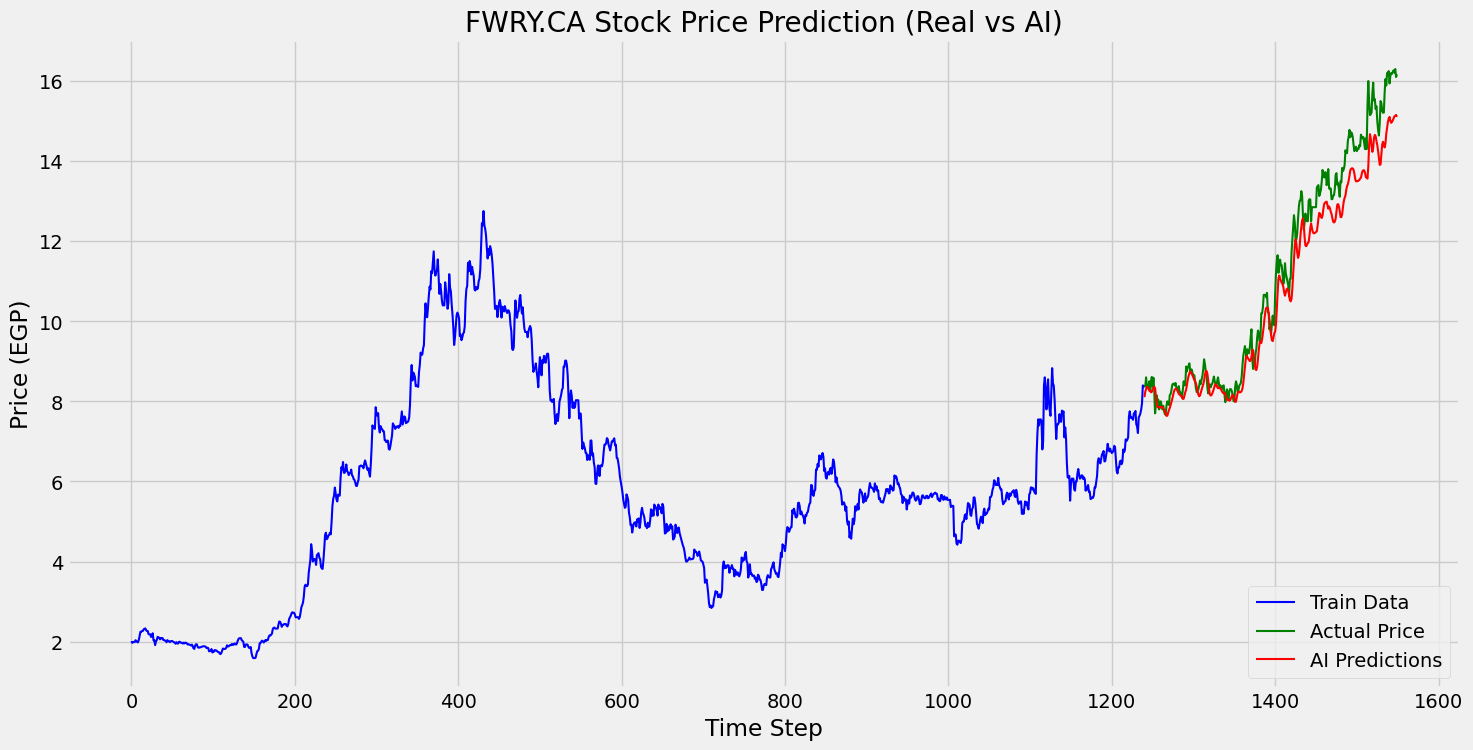

In [7]:
train_df = pd.DataFrame(features[:train_size], columns=['Price'])
test_df = pd.DataFrame(features[train_size:], columns=['Price'])

test_df.index = range(train_size, train_size + len(test_df))

test_df['Predictions'] = np.nan


num_preds = len(predictions_real.flatten())
test_df.iloc[-num_preds:, test_df.columns.get_loc('Predictions')] = predictions_real.flatten()

plt.figure(figsize=(16,8))
plt.plot(train_df['Price'], label='Train Data', color='blue', linewidth=1.5)
plt.plot(test_df['Price'], label='Actual Price', color='green', linewidth=1.5)
plt.plot(test_df['Predictions'], label='AI Predictions', color='red', linewidth=1.5)

plt.title(f'{ticker} Stock Price Prediction (Real vs AI)')
plt.xlabel('Time Step')
plt.ylabel('Price (EGP)')
plt.legend(loc='lower right')
plt.show()